In [32]:
# Import of librarys
import hdbscan #For clustering
import opensmile #For feature extraction
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import k_means
import umap
import hdbscan

In [33]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

df = pd.read_parquet("/home/ashley-bravo/clustering/features_cv200.parquet")

non_feature_cols = ["key", "audio_path", "target"]
feature_cols = [c for c in df.columns if c not in non_feature_cols]
X = df[feature_cols].values

X_scaled = StandardScaler().fit_transform(X)

## K-means

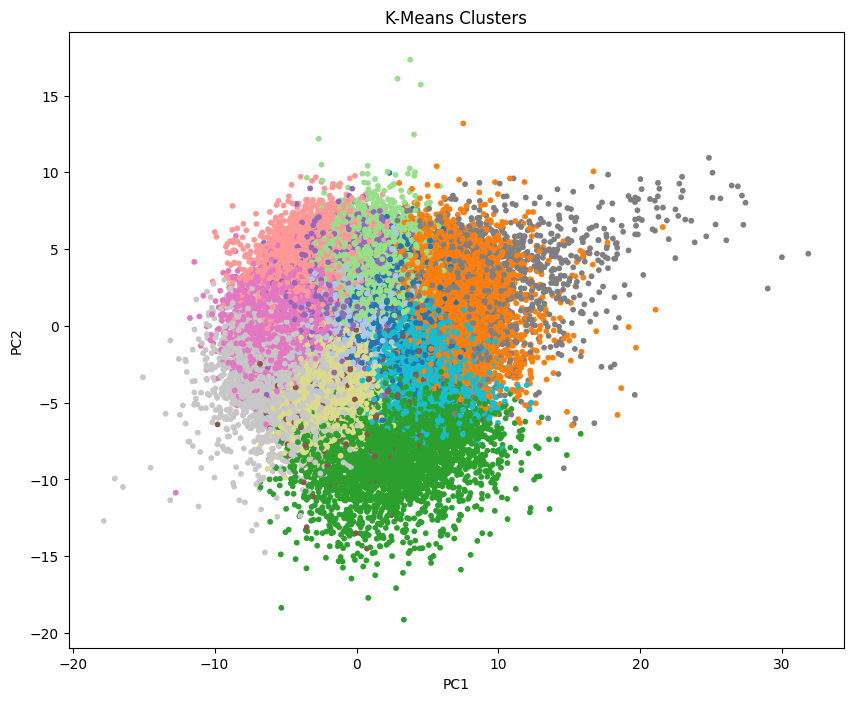

In [4]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# KMeans
kmeans = KMeans(n_clusters=15, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Graficar
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0],X_pca[:, 1],c=labels,cmap="tab20",s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters")
plt.show()


GridSearch

range(3, 15)


k: 3


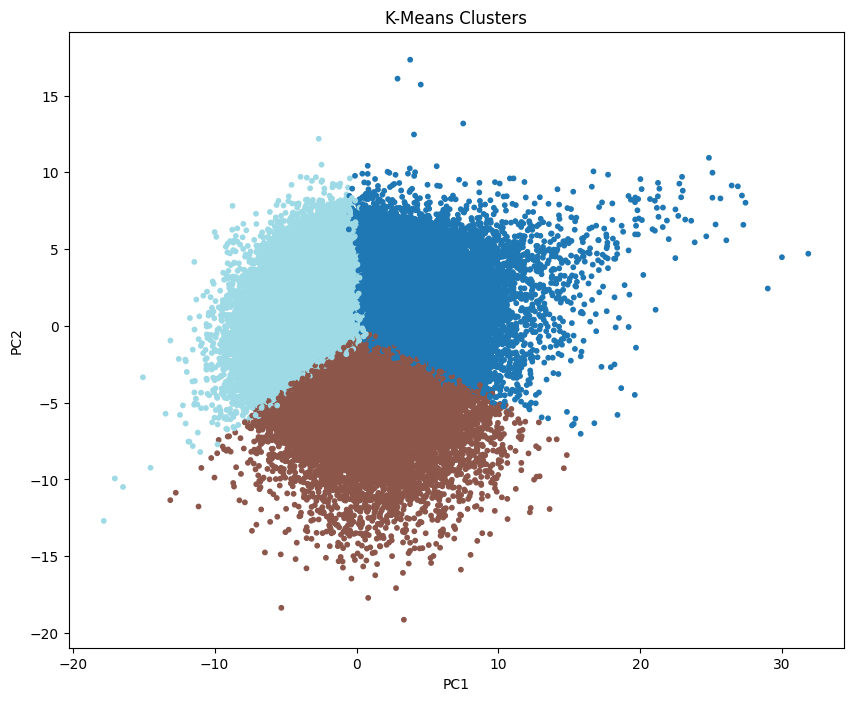

k: 4


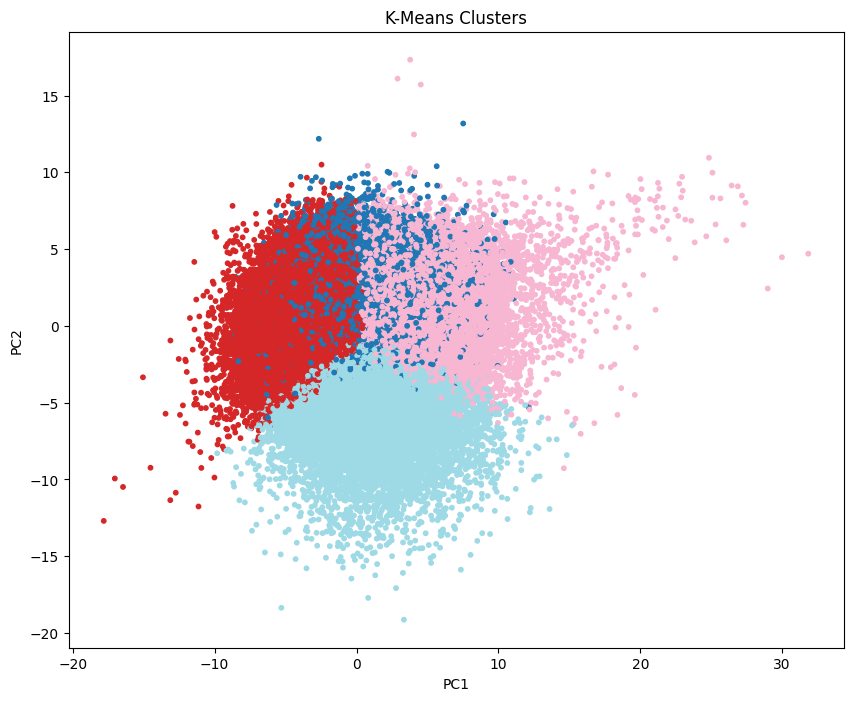

k: 5


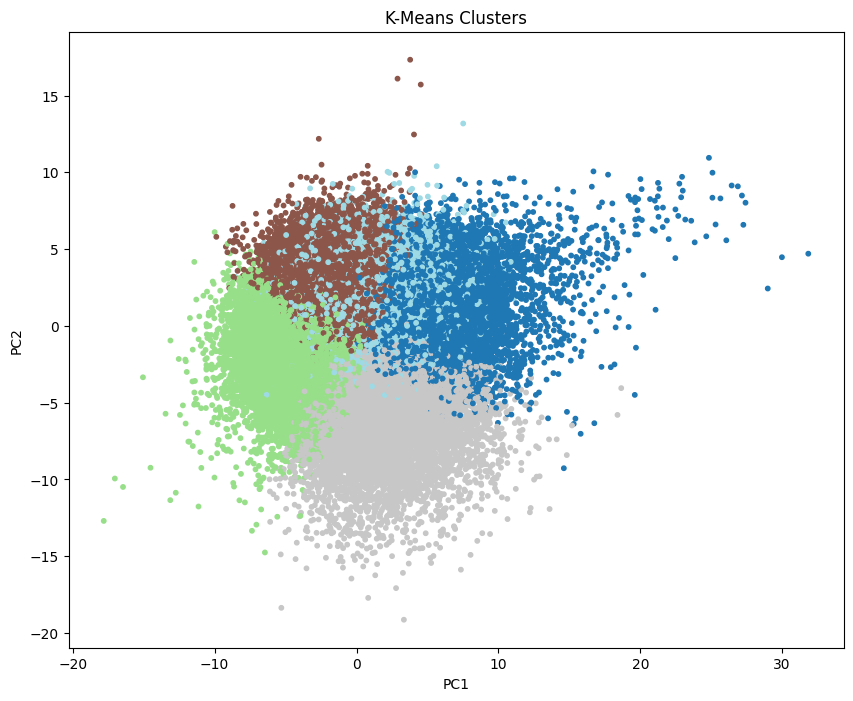

k: 6


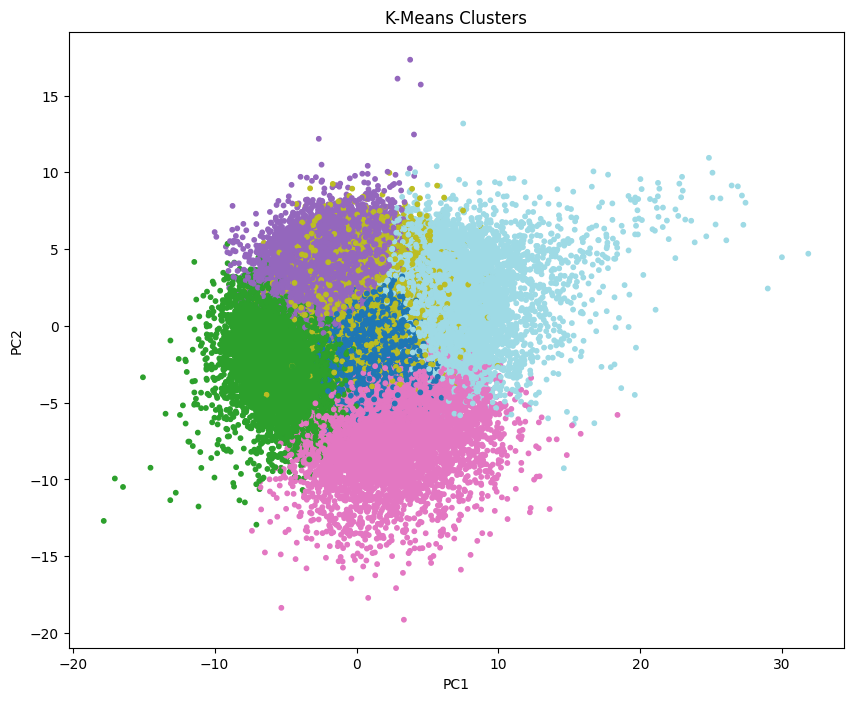

k: 7


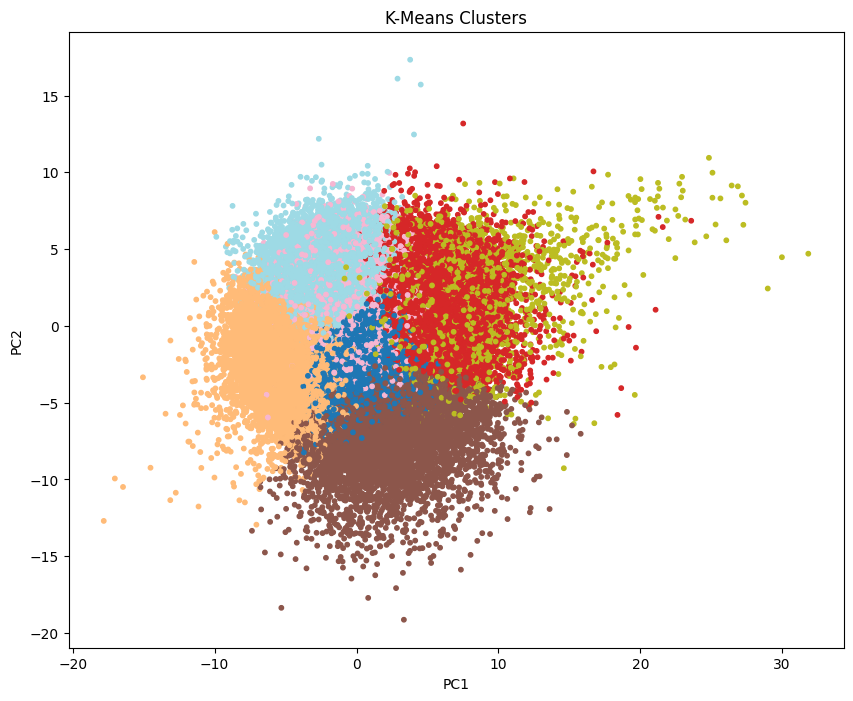

k: 8


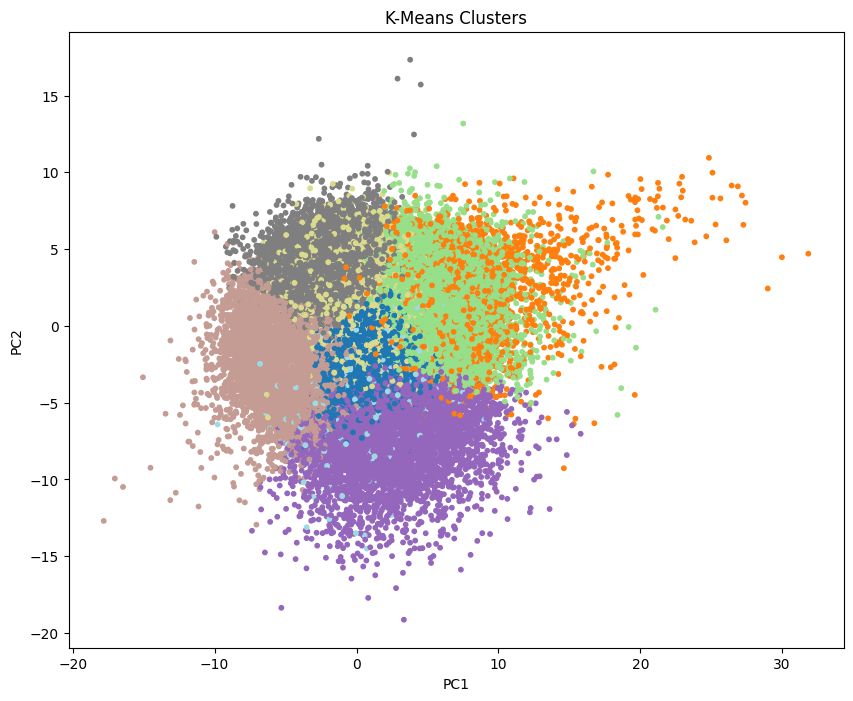

k: 9


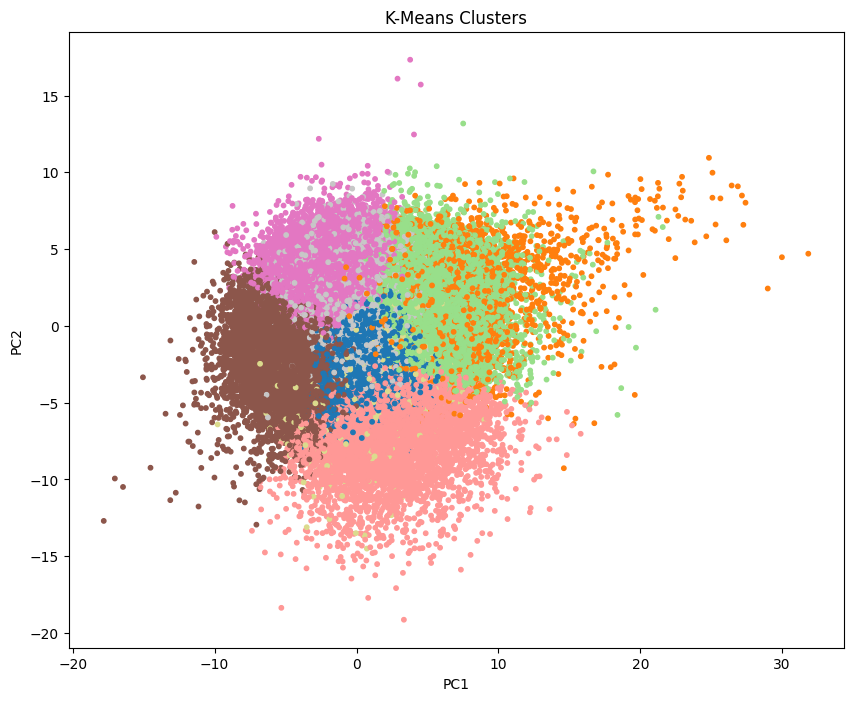

k: 10


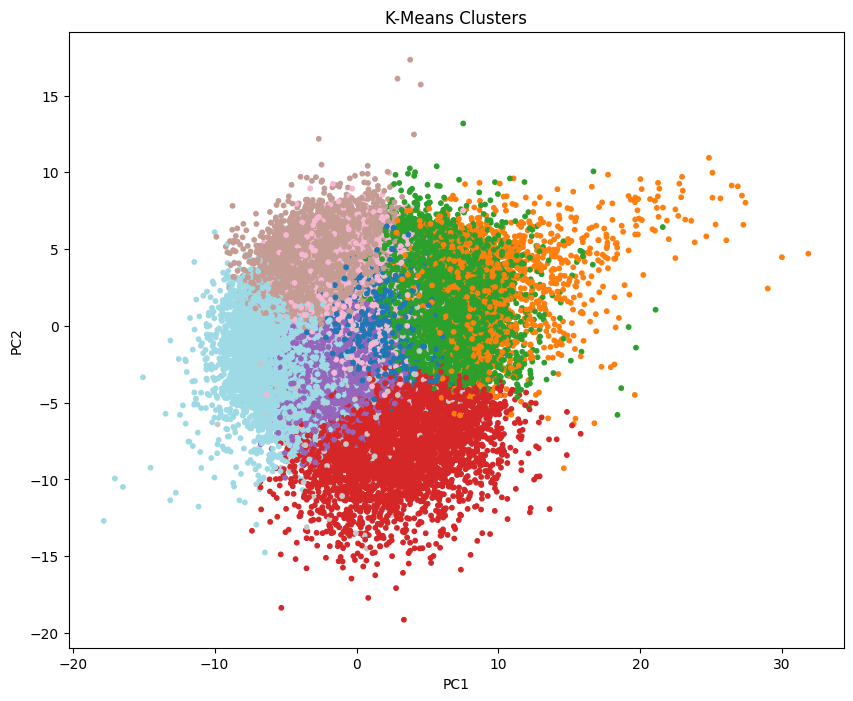

k: 11


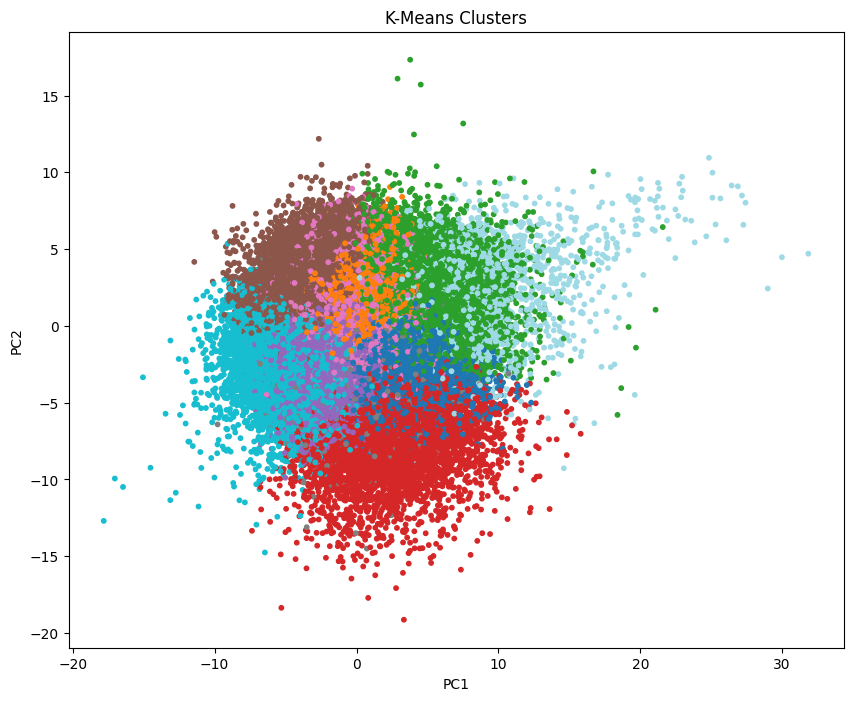

k: 12


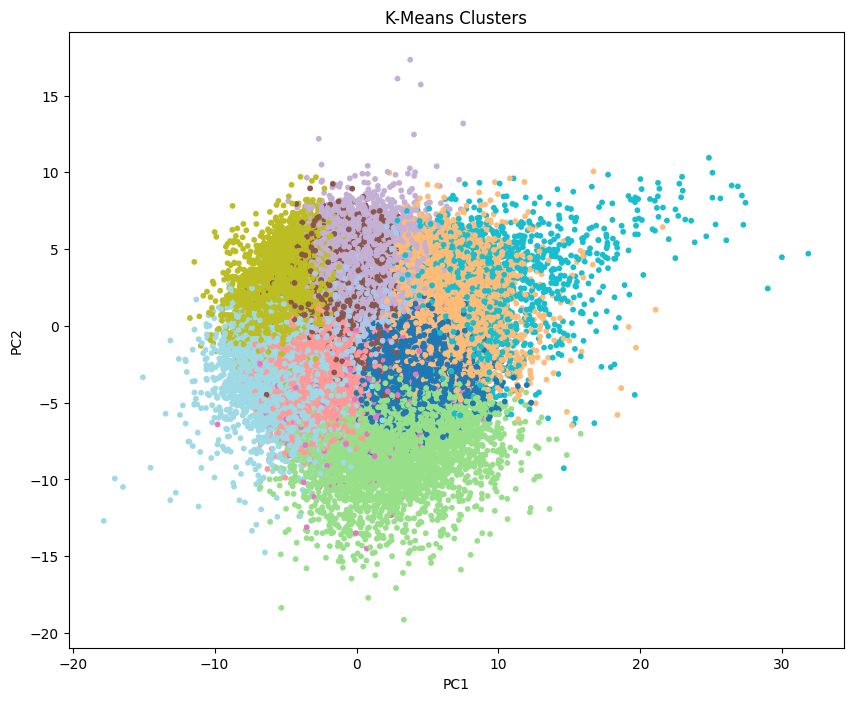

k: 13


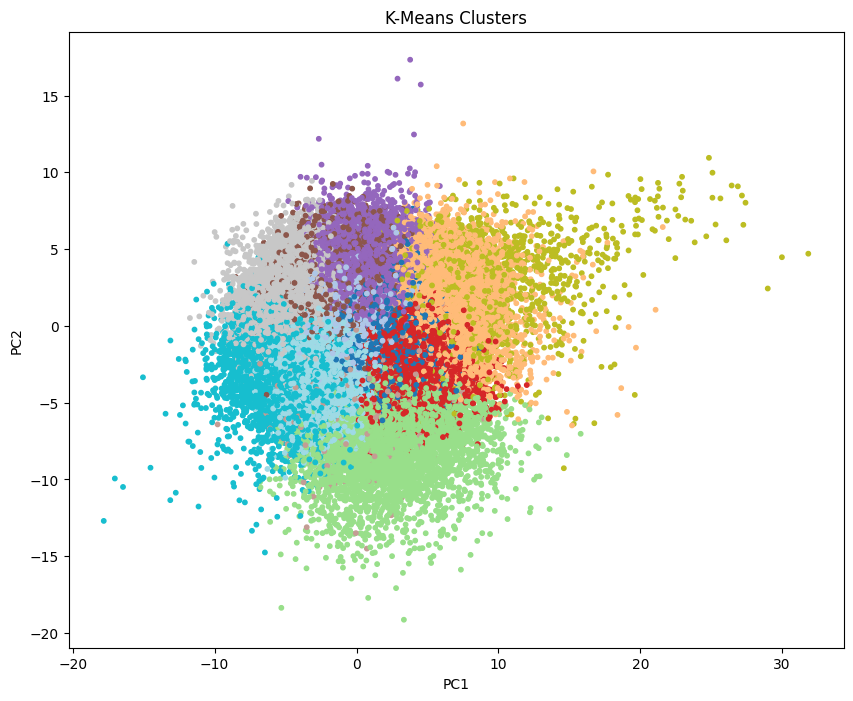

k: 14


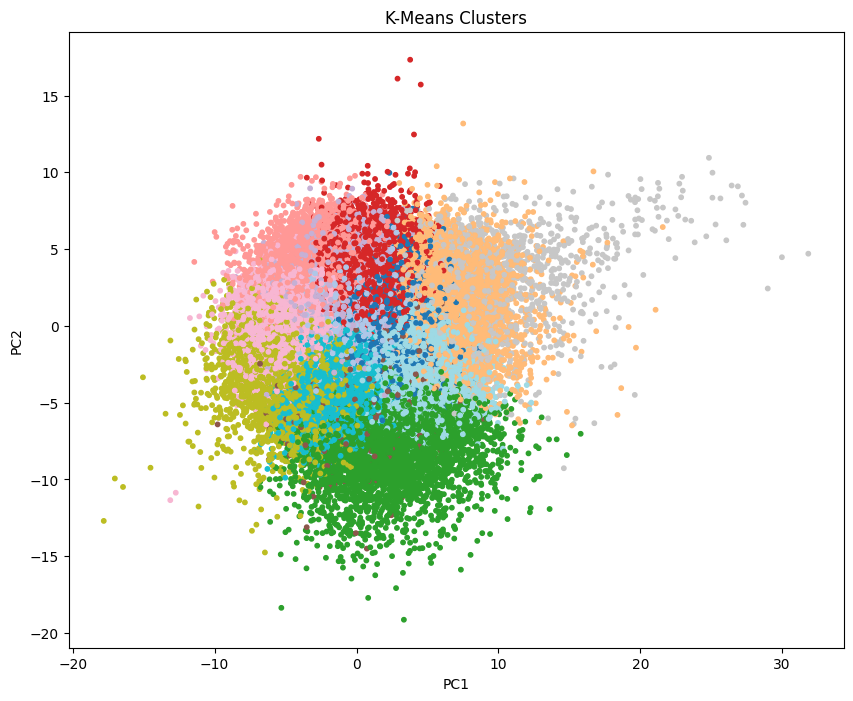

In [29]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


k = range(3,15)
# KMeans
results = []

for k_value in k:
    print("k:", k_value)
    kmeans = KMeans(n_clusters=k_value, random_state=42)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    labels = kmeans.fit_predict(X_scaled)

    # PCA a 2 dimensiones
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Graficar
    plt.figure(figsize=(10, 8))
    plt.scatter(X_pca[:, 0],X_pca[:, 1],c=labels,cmap="tab20",s=10
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("K-Means Clusters")
    plt.show()





## GMM

### Graficos

In [20]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
def graficarGMM(k,reg=1e-6):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        reg_covar=reg,
    )
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    labels = gmm.fit_predict(X_pca)
    bic_value= gmm.bic(X_pca)

    print("BIC",bic_value)
    
    X_vis = PCA(n_components=2, random_state=42).fit_transform(X_pca)

    plt.figure(figsize=(12,10))

    scatter = plt.scatter(
        X_vis[:,0],
        X_vis[:,1],
        c=labels,
        cmap="tab10",
        s=3,
        alpha=0.7
    )

    plt.colorbar(scatter)
    plt.title(f"GMM Clusters K: {k}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.show()

BIC 1231323.669577617


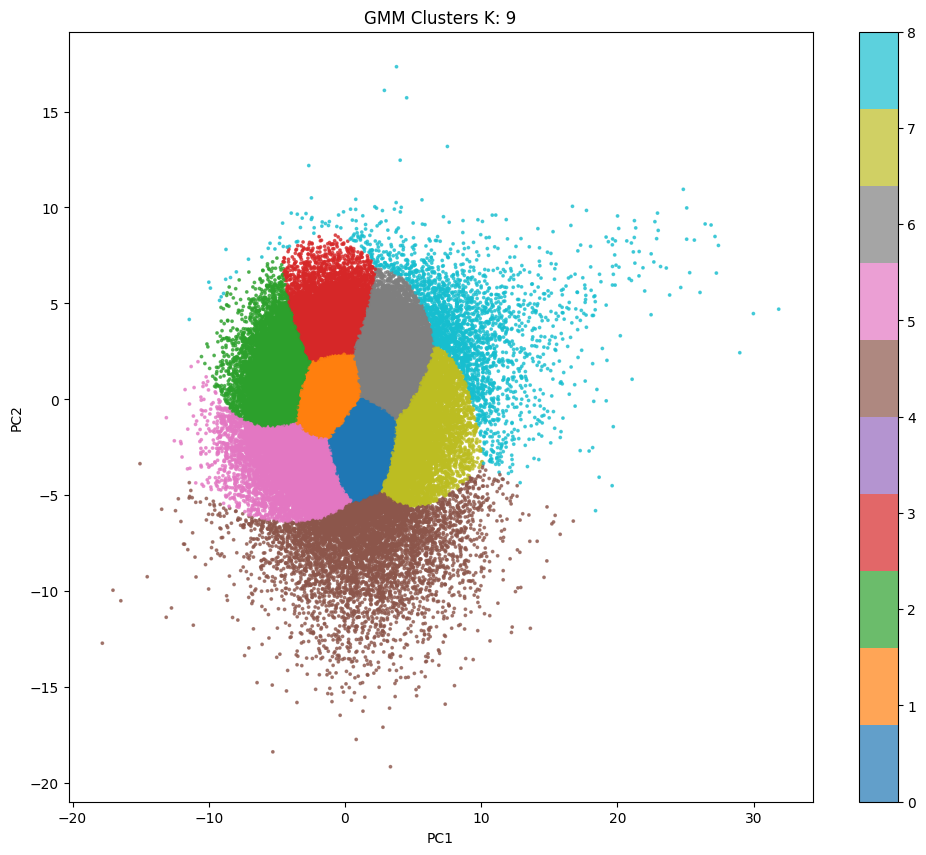

BIC 1232261.1280159417


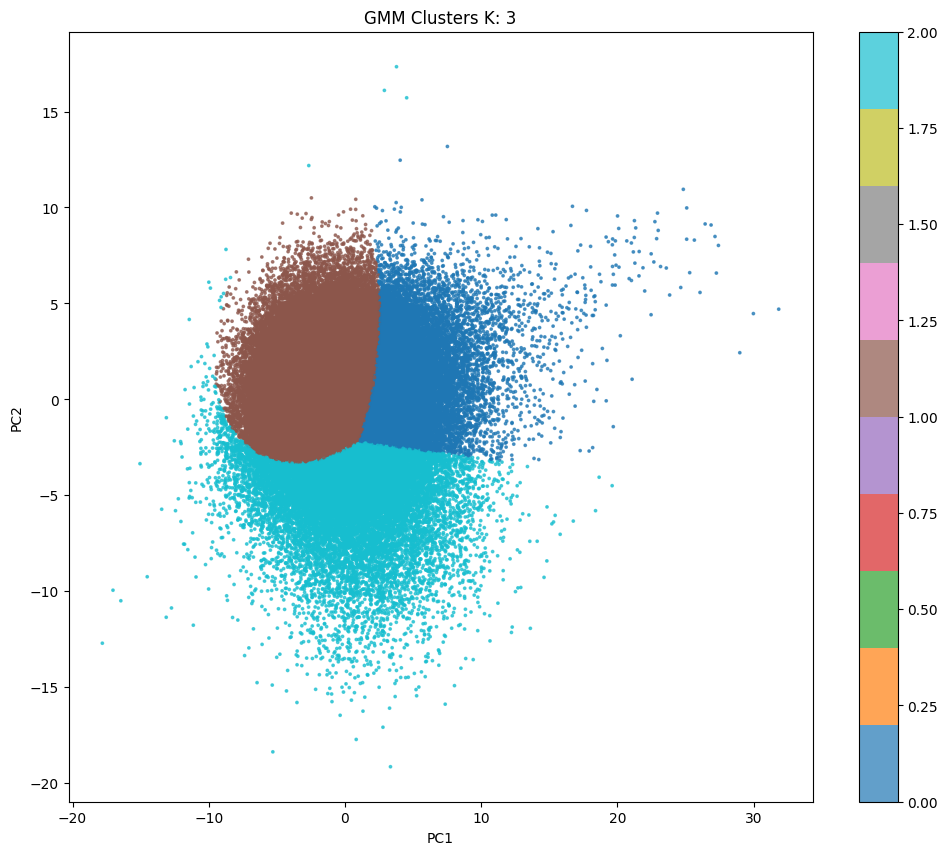

In [30]:
graficarGMM(9)
graficarGMM(3)

### In search of hyperparameters

In [7]:
import numpy as np
import pandas as pd

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------
# Data
# --------------------
X = df[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

X_pca = PCA(n_components=30, random_state=42).fit_transform(X_scaled)

# --------------------
# Grid
# --------------------
n_components_range = range(2, 15)
cov_types = ["full", "tied", "diag", "spherical"]
reg_covars = [1e-6, 1e-5, 1e-4]

results = []

# --------------------
# Search
# --------------------
for cov in cov_types:
    for reg in reg_covars:
        for k in n_components_range:

            gmm = GaussianMixture(
                n_components=k,
                covariance_type=cov,
                reg_covar=reg,
                random_state=42
            )

            gmm.fit(X_pca)

            bic = gmm.bic(X_pca)

            results.append({
                "k": k,
                "covariance": cov,
                "reg_covar": reg,
                "bic": bic
            })

# --------------------
# Results
# --------------------
df_results = pd.DataFrame(results)

best = df_results.loc[df_results["bic"].idxmin()]

print("BEST MODEL:")
print(best)

BEST MODEL:
k                        14
covariance             full
reg_covar          0.000001
bic           211809.817351
Name: 12, dtype: object


BIC 1231630.5831964023


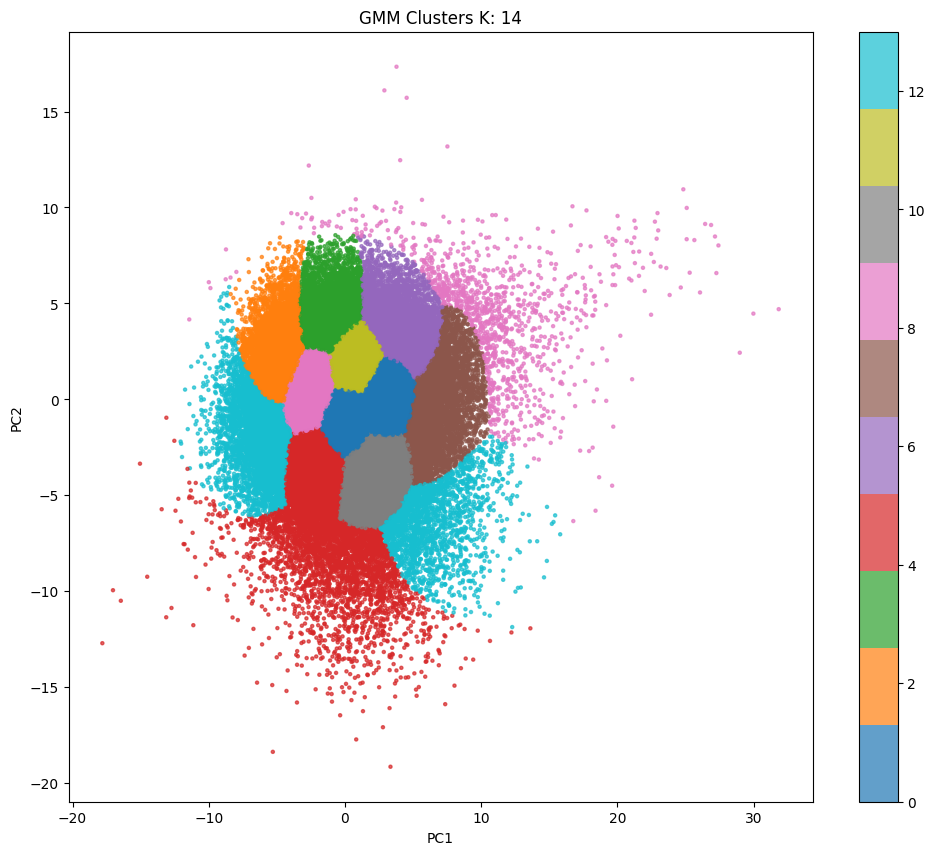

In [11]:
graficarGMM(14)


### Result

In [34]:
gmm = GaussianMixture(n_components=14,covariance_type="full",random_state=42,reg_covar=1e-6)
pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)
labels = gmm.fit_predict(X_pca)
df["cluster"] = labels
bic_value= gmm.bic(X_pca)

print("BIC",bic_value)

df["cluster"].value_counts()

BIC 211809.81735108397


cluster
3     28173
6     27428
13    22692
4     14274
1      5267
12     5120
7      3909
9      3133
2      2139
5      2132
11     1680
8      1628
0       880
10      473
Name: count, dtype: int64

In [37]:
probs = gmm.predict_proba(X_pca)
df["confidence"] = probs.max(axis=1)
df[df["confidence"] > 0.8]["cluster"].value_counts()

cluster
3     24244
6     22260
13    17670
4     12124
12     4626
1      4537
7      3496
9      2962
2      1950
5      1874
11     1474
8      1427
0       819
10      473
Name: count, dtype: int64

In [38]:
print(df.columns.tolist())

['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean', 'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0', 'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0', 'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope', 'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope', 'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean', 'spectralFlux_sma3_stddevNorm', 'mfcc1_sma3_amean', 'mfcc1_sma3_stddevNorm', 'mfcc2_sma3_amean', 'mfcc2_sma3_stddevNorm', 'mfcc3_sma3_amean', 'mfcc3_sma3_stddevNorm', 'mfcc4_sma3_amean', 'mfcc4_sma3_std

In [39]:

# Ver tamaño de clusters
cluster_counts = df["cluster"].value_counts()

print(cluster_counts)

# Seleccionar los 4 clusters más grandes
top_clusters = cluster_counts.head(4).index.tolist()

print("Clusters seleccionados:", top_clusters)

MAX_SECONDS = 10 * 3600

cluster
3     28173
6     27428
13    22692
4     14274
1      5267
12     5120
7      3909
9      3133
2      2139
5      2132
11     1680
8      1628
0       880
10      473
Name: count, dtype: int64
Clusters seleccionados: [3, 6, 13, 4]


In [40]:
import json

def save_jsonl(df_subset, output_path):
    with open(output_path, "w", encoding="utf-8") as f:
        for row in df_subset.itertuples(index=False):

            sample = {
                "key": row.key,
                "source": row.audio_path,
                "target": row.target
            }

            json.dump(sample, f, ensure_ascii=False)
            f.write("\n")

In [41]:
import soundfile as sf

def get_duration(audio_path):
    info = sf.info(audio_path)
    return info.frames / info.samplerate

df["duration"] = df["audio_path"].apply(get_duration)

In [50]:
!nvidia-smi

Sat Jun 27 03:41:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.43.02     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    On  |   00000000:03:00.0 Off |                    0 |
| N/A   68C    P0            325W /  350W |   43081MiB /  46068MiB |     98%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [49]:
!kill -9 2466299

In [42]:
MAX_SECONDS = 10 * 3600

for cluster_id in top_clusters:

    df_cluster = (
        df[df["cluster"] == cluster_id]
        .sort_values("confidence", ascending=False)
        .copy()
    )

    df_cluster["cum_duration"] = df_cluster["duration"].cumsum()

    df_selected = df_cluster[
        df_cluster["cum_duration"] <= MAX_SECONDS
    ].copy()

    print(
        f"Cluster {cluster_id}: "
        f"{len(df_selected)} audios | "
        f"{df_selected['duration'].sum()/3600:.2f} horas"
    )

    save_jsonl(
        df_selected,
        f"cluster_{cluster_id}_10h.jsonl"
    )

Cluster 3: 6092 audios | 10.00 horas
Cluster 6: 5503 audios | 10.00 horas
Cluster 13: 6255 audios | 10.00 horas
Cluster 4: 5832 audios | 10.00 horas


### Interactive

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import ipywidgets as widgets
from IPython.display import display

# ---- data ----
X = df[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

In [7]:
def run_gmm(k=3, cov_type="full", pca_dim=30):

    # ---- PCA ----
    X_pca = PCA(n_components=pca_dim, random_state=42).fit_transform(X_scaled)

    # ---- GMM ----
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=cov_type,
        random_state=42
    )

    labels = gmm.fit_predict(X_pca)
    bic = gmm.bic(X_pca)

    # ---- 2D projection for visualization ----
    X_vis = PCA(n_components=2, random_state=42).fit_transform(X_pca)

    plt.figure(figsize=(10,8))

    plt.scatter(
        X_vis[:,0],
        X_vis[:,1],
        c=labels,
        cmap="tab10",
        s=5,
        alpha=0.7
    )

    plt.title(f"GMM | K={k} | cov={cov_type} | BIC={bic:.2f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    print("BIC:", bic)

In [ ]:
k_slider = widgets.IntSlider(
    value=3,
    min=2,
    max=15,
    step=1,
    description="K"
)

cov_dropdown = widgets.Dropdown(
    options=["full", "tied", "diag", "spherical"],
    value="full",
    description="Cov"
)

pca_slider = widgets.IntSlider(
    value=30,
    min=5,
    max=80,
    step=5,
    description="PCA dim"
)

ui = widgets.VBox([k_slider, cov_dropdown, pca_slider])

out = widgets.interactive_output(
    run_gmm,
    {
        "k": k_slider,
        "cov_type": cov_dropdown,
        "pca_dim": pca_slider
    }
)

display(ui, out)